# Single Band Photometry and Matching

## 1. Initial Setting

In [1]:
from astropy.table import Table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import (
    ImageNormalize,
    ZScaleInterval,
    PercentileInterval,
    AsinhStretch,
    LogStretch,
    SqrtStretch
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import glob
from pathlib import Path
import subprocess
from tqdm.auto import tqdm
import random

def get_image_path(cosmos, band, weight=False):
    image_folder = DATA_ROOT / f"COSMOS{cosmos}"

    suffix = "weight.fits" if weight else "com.fits"
    paths = list(image_folder.glob(f"*{band}*.{suffix}"))

    if len(paths) == 0:
        print(
            f"COSMOS {cosmos} - {band}: no matching {suffix} file."
        )
        return None

    if len(paths) > 1:
        raise RuntimeError(
            f"COSMOS {cosmos} - {band}: multiple matching {suffix} files."
        )

    return paths[0]

def get_catalog_path(cosmos, band):
    return PROJECT_ROOT / f'output/COSMOS{COSMOS}/singlebandphot/cat_cosmos{cosmos}_{band}.fits'

def plot_ImageAndDetectedSources(image, cat, center_point=None, length=None, show_source_id=True):
    if center_point is not None and length is not None:
        half = length / 2
        xmin = max(0, int(center_point[0] - half))
        xmax = min(image.shape[1], int(center_point[0] + half))
        ymin = max(0, int(center_point[1] - half))
        ymax = min(image.shape[0], int(center_point[1] + half))

        cat_plot = cat[
            (xmin <= cat['pixel_centroid_x'])
            & (cat['pixel_centroid_x'] < xmax)
            & (ymin <= cat['pixel_centroid_y'])
            & (cat['pixel_centroid_y'] < ymax)
        ]

        image_plot = image[ymin:ymax, xmin:xmax]

    else:
        ymin, xmin = 0, 0
        ymax, xmax = image.shape

        cat_plot = cat
        image_plot = image

    norm = ImageNormalize(
        image_plot,
        interval=ZScaleInterval(),
        #stretch=
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax]
    )

    radius_pix = 5.94

    for x, y, source_id in zip(
        cat_plot['pixel_centroid_x'],
        cat_plot['pixel_centroid_y'],
        cat_plot['source_id']
    ):
        ax.add_patch(
            Circle(
                (x, y),
                radius=radius_pix,
                fill=False,
                edgecolor='red',
                linewidth=1
            )
        )

        if show_source_id and length is not None and length < 500:
            ax.text(
                x + radius_pix,
                y + radius_pix,
                str(source_id),
                color='yellow',
                fontsize=7,
                ha='left',
                va='bottom',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1),
            )

    # Draw crosshair at center_point
    if center_point is not None:
        ax.axhline(y=center_point[1], color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axvline(x=center_point[0], color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)

    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')

    plt.show()

# Image preparation
COSMOS = 1
PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT/'COSMOS_data'
BANDS_7DT = [f"m{i}" for i in range(400, 900, 25)]
MASK_ROOT = DATA_ROOT / f"COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits"

valid_mask = fits.open(MASK_ROOT)[0].data
valid_mask = valid_mask.astype(bool)

# Make available bands
available_band = []
image_paths = {}
weight_paths = {}
zero_points = {}

for band in BANDS_7DT : 
    band_path = get_image_path(COSMOS, band)
    weight_path = get_image_path(COSMOS, band, weight=True)
    if band_path is None : continue
    available_band.append(band)
    image_paths[band] = band_path
    weight_paths[band] = weight_path
    with fits.open(band_path) as hdul : 
        header = hdul[0].header
    zero_points[band] = float(header['ZP_3'])

print(f'{len(available_band)} bands are available.')

first_band = available_band[0]
with fits.open(image_paths[first_band]) as hdul : 
    data = hdul[0].data
    wcs = WCS(hdul[0].header)


# <============ Important settings ============>

PIXEL_SCALE = (proj_plane_pixel_scales(wcs)[0] * u.deg).to(u.arcsec)
APER_3ARCSEC_PIXEL = 3 * u.arcsec / PIXEL_SCALE
DETECTION_THRESHOLD = 3
DETECTION_MINIMUM_AREA = 3
THREAD_COUNT = 1


20 bands are available.


## 2. Single Band Photometry

In [5]:
for band in tqdm(available_band):
    image_path = image_paths[band]
    weight_path = weight_paths[band]

    pyconfig_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.py"
    config_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.config"
    pyconfig_path.parent.mkdir(parents=True, exist_ok=True)
    zero_point = zero_points[band]
    
    catalog_path = (
        PROJECT_ROOT
        / f"output/COSMOS{COSMOS}/singlebandphot"
        / f"cat_cosmos{COSMOS}_{band}.fits"
    )
    catalog_path.parent.mkdir(parents=True, exist_ok=True)

    pyconfig_code = f"""
from sourcextractor.config import *

image_group = load_fits_image(
    {str(image_path)!r},
    # weight={str(weight_path)!r},
    # weight_type='weight'
)

meas_group = MeasurementGroup(image_group)

aper = []

for img in meas_group:
    aper.extend(
        add_aperture_photometry(
            img,
            {APER_3ARCSEC_PIXEL}
        )
    )

add_output_column("aper3", aper)
"""


    config_code = f"""
detection-image={image_path}

detection-threshold={DETECTION_THRESHOLD}
detection-minimum-area={DETECTION_MINIMUM_AREA}
magnitude-zero-point={zero_point}

python-config-file={pyconfig_path}

output-properties=SourceIDs,PixelCentroid,WorldCentroid,AperturePhotometry,SNRRatio,ShapeParameters,FluxRadius
output-catalog-filename={catalog_path}

segmentation-use-filtering=false
thread-count={THREAD_COUNT}
"""
    pyconfig_path.write_text(pyconfig_code)
    config_path.write_text(config_code) 
    
    command = [
        'sourcextractor++', 
        '--config-file', 
        str(config_path)
    ]
    
    subprocess.run(command, check=True)

print('Single Band Catalog Process finished')

  0%|          | 0/20 [00:00<?, ?it/s]

2026-09-09T14:34:05KST FitsFile  INFO : Creating shared LRUFileManager with limit of 500 open files.
2026-09-09T14:34:06KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits)) with 0.0 weight image masked pixels; median: 1.11128 rms: 1.97927!
2026-09-09T14:34:07KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits)) with 0.0 weight image masked pixels; median: 1.11128 rms: 1.97927!
2026-09-09T14:34:07KST FlexibleModelFitting  INFO : Using engine levmar with the iterative implementation and 200 maximum number of iterations, window type: 1
2026-09-09T14:34:07KST SourceXtractor  INFO : Writing output following segmentation order
2026-09-09T14:34:07KST SourceXtractor  INFO : Processing frame 1 / 1 : calib_7DT_COSMOS_1_20240528_2

Single Band Catalog Process finished


2026-09-09T14:44:21KST SourceXtractor  INFO : 36936 sources detected in frame, 36936 total
2026-09-09T14:44:21KST Progress  INFO : Segmentation: 6800 / 6800 (100.00%)
2026-09-09T14:44:21KST Progress  INFO : Detected: 212843
2026-09-09T14:44:21KST Progress  INFO : Deblended: 36936
2026-09-09T14:44:21KST Progress  INFO : Measured: 36936 / 36936 (100.00%)
2026-09-09T14:44:21KST Progress  INFO : Elapsed: 00:00:38
2026-09-09T14:44:21KST SourceXtractor  INFO : total 36936 sources detected
2026-09-09T14:44:21KST Python::Interpreter  INFO : Python GIL acquired 19 times


Check the result

  0%|          | 0/20 [00:00<?, ?it/s]

m400: 1815 good sources


m425: 3452 good sources


m450: 2467 good sources


m475: 4163 good sources


m500: 4003 good sources


m525: 5347 good sources


m550: 2934 good sources


KeyboardInterrupt: 

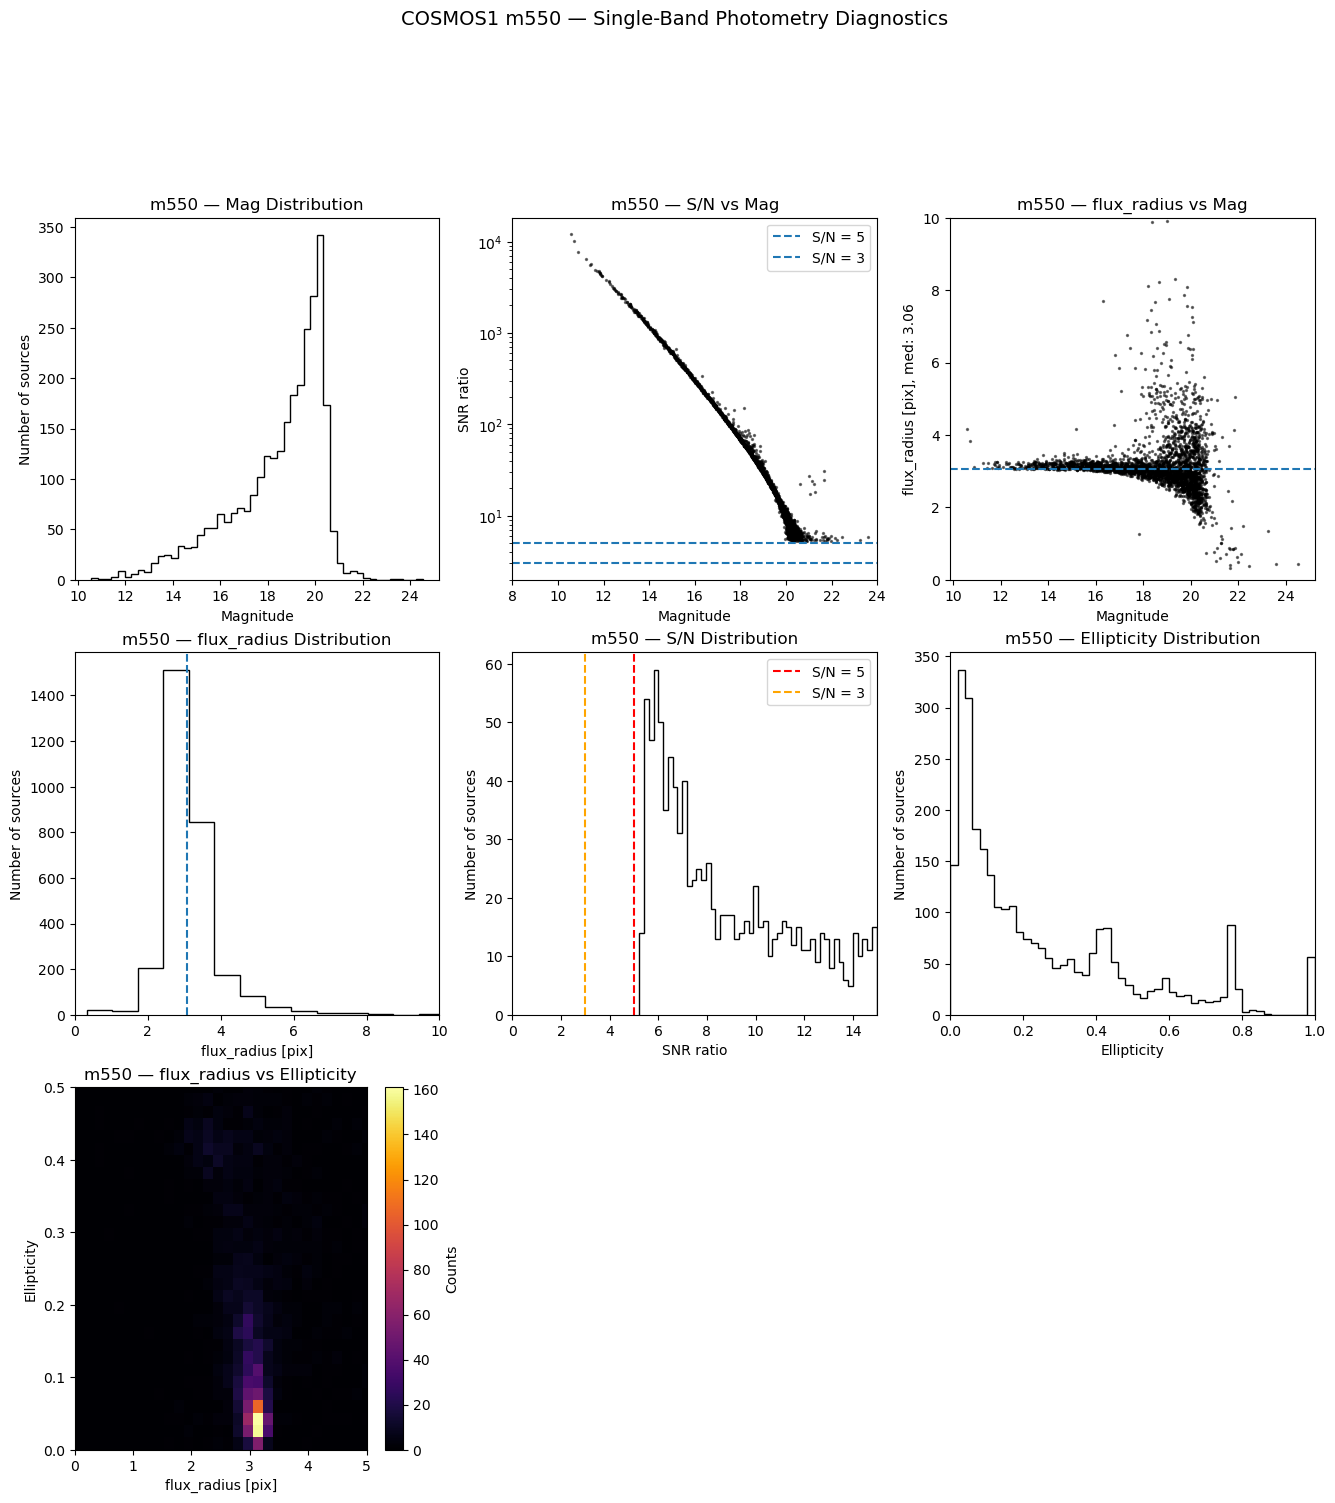

In [2]:
save_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/figures"
save_dir.mkdir(parents=True, exist_ok=True)

for band in tqdm(available_band):
    catalog_path = (
        PROJECT_ROOT
        / f"output/COSMOS{COSMOS}/singlebandphot"
        / f"cat_cosmos{COSMOS}_{band}.fits"
    )
    
    cat = Table.read(catalog_path)
    cat = cat[cat['aper3_flags']==0]
    
    # valid_mask filtering
    cat_x = np.rint(cat['pixel_centroid_x']).astype(int)
    cat_y = np.rint(cat['pixel_centroid_y']).astype(int)
    valid_source = valid_mask[cat_y, cat_x]
    cat = cat[valid_source]
    cat = cat[(cat['aper3_flags']==0) & (cat['flux_radius'] > 0) & (cat['aper3_mag'] > 5)]
    
    print(f'{band}: {len(cat)} good sources')
    
    # --- 3x3 subplot ---
    mag = np.asarray(cat['aper3_mag'])
    snr = np.asarray(cat['snrratio'])
    flux_radius = np.asarray(cat['flux_radius'])
    ellipticity = np.asarray(cat['ellipticity'])
    
    # --- calculate flux_radius median ---
    r50_mean, r50_med, r50_std = sigma_clipped_stats(flux_radius)
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    
    # --- [0,0] Magnitude Histogram ---
    axes[0,0].hist(mag, bins=50, histtype='step', color='black')
    axes[0,0].set_xlabel("Magnitude")
    axes[0,0].set_ylabel("Number of sources")
    axes[0,0].set_title(f"{band} — Mag Distribution")
    
    # --- [0,1] SNR vs Magnitude ---
    axes[0,1].scatter(mag, snr, s=2, marker='o', alpha=0.5, color='black')
    axes[0,1].set_xlabel("Magnitude")
    axes[0,1].set_ylabel("SNR ratio")
    axes[0,1].set_yscale('log')
    axes[0,1].set_xlim(8, 24)
    axes[0,1].axhline(5, linestyle="--", label="S/N = 5")
    axes[0,1].axhline(3, linestyle="--", label="S/N = 3")
    axes[0,1].legend()
    axes[0,1].set_title(f"{band} — S/N vs Mag")
    
    # --- [0,2] flux_radius vs Magnitude ---
    axes[0,2].scatter(mag, flux_radius, s=2, marker='o', alpha=0.5, color='black')
    axes[0,2].set_xlabel("Magnitude")
    axes[0,2].set_ylabel(f"flux_radius [pix], med: {r50_med:.2f}")
    axes[0,2].set_ylim(0, 10)
    axes[0,2].axhline(r50_med, linestyle="--")
    axes[0,2].set_title(f"{band} — flux_radius vs Mag")
    
    # --- [1,0] flux_radius Histogram ---
    axes[1,0].hist(flux_radius, bins=100, histtype='step', color='black')
    axes[1,0].axvline(r50_med, linestyle="--", label="r50_median")
    axes[1,0].set_xlabel("flux_radius [pix]")
    axes[1,0].set_ylabel("Number of sources")
    axes[1,0].set_title(f"{band} — flux_radius Distribution")
    axes[1,0].set_xlim(0, 10)
    
    # --- [1,1] S/N Histogram ---
    snr_hist = snr[snr<15]
    axes[1,1].hist(snr_hist, bins=50, histtype='step', color='black')
    axes[1,1].set_xlabel("SNR ratio")
    axes[1,1].set_ylabel("Number of sources")
    axes[1,1].set_title(f"{band} — S/N Distribution")
    axes[1,1].axvline(5, linestyle="--", color='red', label="S/N = 5")
    axes[1,1].axvline(3, linestyle="--", color='orange', label="S/N = 3")
    axes[1,1].set_xlim(0, 15)
    axes[1,1].legend()
    
    # --- [1,2] Ellipticity Histogram ---
    axes[1,2].hist(ellipticity, bins=50, histtype='step', color='black')
    axes[1,2].set_xlabel("Ellipticity")
    axes[1,2].set_ylabel("Number of sources")
    axes[1,2].set_title(f"{band} — Ellipticity Distribution")
    axes[1,2].set_xlim(0, 1)
    
    # --- [2,0] flux_radius vs Ellipticity 2D Histogram ---
    h = axes[2,0].hist2d(
        flux_radius, ellipticity,
        bins=[np.linspace(0, 10, 60), np.linspace(0, 1, 60)],
        cmap='inferno'
    )
    plt.colorbar(h[3], ax=axes[2,0], label="Counts")
    axes[2,0].set_xlabel("flux_radius [pix]")
    axes[2,0].set_ylabel("Ellipticity")
    axes[2,0].set_title(f"{band} — flux_radius vs Ellipticity")
    axes[2,0].set_xlim(0, 5)
    axes[2,0].set_ylim(0, 0.5)
    
    # --- Hide unused subplots ---
    axes[2,1].axis('off')
    axes[2,2].axis('off')
    
    fig.suptitle(f"COSMOS{COSMOS} {band} — Single-Band Photometry Diagnostics", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(save_dir / f'info_{band}.png', dpi=150, bbox_inches='tight')
    plt.close()
    


plot image and detected sources & compare with detection image in multi-band phot

['source_id', 'detection_id', 'pixel_centroid_x', 'pixel_centroid_y', 'world_centroid_alpha', 'world_centroid_delta', 'aper3_flux', 'aper3_flux_err', 'aper3_mag', 'aper3_mag_err', 'aper3_flags', 'snrratio', 'ellipse_a', 'ellipse_b', 'ellipse_theta', 'ellipse_cxx', 'ellipse_cyy', 'ellipse_cxy', 'area', 'elongation', 'ellipticity', 'flux_radius']
Detected Sources : 7888

        idx : 1302 
        source_id : 38942
        mag : 20.421768188476562 
        snr : 9.003372192382812
        flux_radius : 2.974477529525757
        ellipticity : 0.5829224586486816
        


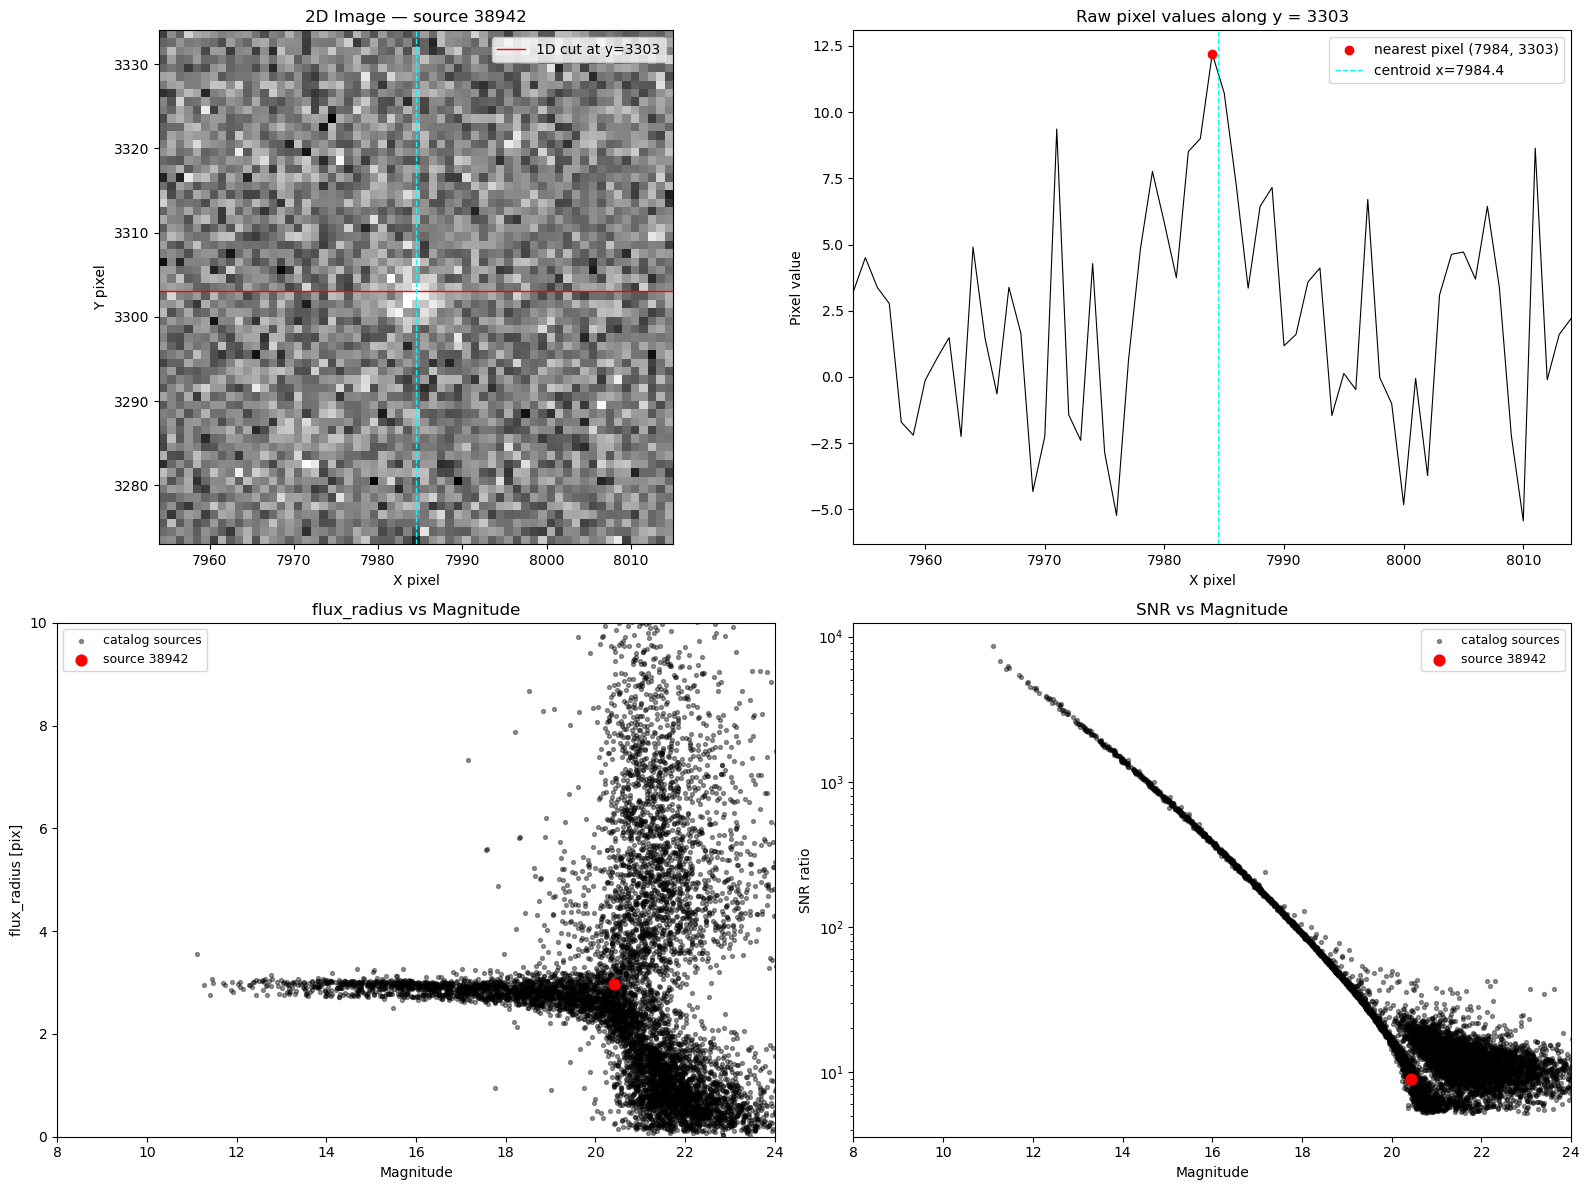

In [18]:
def plot_SourceExampleInCatalog(image, cat, length=10, source_id=None, selection=None):
    cat_original = cat
    if selection is not None : 
        cat = cat[selection]
    
    if source_id is None:
        idx = random.randrange(len(cat))
    else:
        idx = np.where(cat['source_id'] == source_id)[0]
        if len(idx) > 0:
            idx = idx[0]
        else:
            raise ValueError(f'{source_id} not found in catalog')

    print(
        f'''
        idx : {idx} 
        source_id : {cat['source_id'][idx]}
        mag : {cat['aper3_mag'][idx]} 
        snr : {cat['snrratio'][idx]}
        flux_radius : {cat['flux_radius'][idx]}
        ellipticity : {cat['ellipticity'][idx]}
        '''
    )
    
    xlim = image.shape[1]
    ylim = image.shape[0]

    center_point_x = float(cat['pixel_centroid_x'][idx])
    center_point_y = float(cat['pixel_centroid_y'][idx])
    x_center = int(np.rint(center_point_x))
    y_cut = int(np.rint(center_point_y))

    if not (0 <= x_center < xlim and 0 <= y_cut < ylim):
        raise ValueError(
            f'Source centroid is outside the image: '
            f'x={center_point_x}, y={center_point_y}'
        )

    xmin = max(0, x_center - length)
    xmax = min(xlim, x_center + length + 1)
    ymin = max(0, y_cut - length)
    ymax = min(ylim, y_cut + length + 1)
    
    image_plot = image[ymin:ymax, xmin:xmax]
    
    # --- 1D pixel cut along the exact horizontal crosshair row ---
    x_pixels = np.arange(xmin, xmax)
    pixel_values = np.asarray(image[y_cut, xmin:xmax], dtype=float)
    
    # --- 2D image, 1D profile, and catalog diagnostics ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                         gridspec_kw={'width_ratios': [1, 1]})
    ax_img, ax_1d = axes[0]
    ax_flux, ax_snr = axes[1]
    
    # 1. 2D pixel Plot
    norm = ImageNormalize(
        image_plot,
        interval=ZScaleInterval(),
    )

    ax_img.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax],
    )
    ax_img.axhline(y=y_cut, color='red', linestyle='-', linewidth=1,
                   label=f'1D cut at y={y_cut}')
    ax_img.axvline(x=center_point_x, color='cyan', linestyle='--', linewidth=1)
    ax_img.legend(fontsize=10, loc='upper right')
    ax_img.set_xlabel('X pixel')
    ax_img.set_ylabel('Y pixel')
    ax_img.set_title(f'2D Image — source {cat["source_id"][idx]}')
    
    # 2. 1D pixel graph (horizontal cut)
    ax_1d.plot(x_pixels, pixel_values, color='black', linewidth=0.8)
    ax_1d.scatter(x_center, image[y_cut, x_center], color='red', zorder=3,
                  label=f'nearest pixel ({x_center}, {y_cut})')
    ax_1d.axvline(x=center_point_x, color='cyan', linestyle='--', linewidth=1,
                  label=f'centroid x={center_point_x:.1f}')
    ax_1d.set_xlabel('X pixel')
    ax_1d.set_ylabel('Pixel value')
    ax_1d.set_xlim(xmin, xmax - 1)
    ax_1d.set_title(f'Raw pixel values along y = {y_cut}')
    ax_1d.legend(fontsize=10)
    
    # 3. flux_radius vs magnitude
    mag = np.asarray(cat_original['aper3_mag'], dtype=float)
    flux_radius = np.asarray(cat_original['flux_radius'], dtype=float)
    snr = np.asarray(cat_original['snrratio'], dtype=float)

    valid_flux = np.isfinite(mag) & np.isfinite(flux_radius)
    valid_snr = np.isfinite(mag) & np.isfinite(snr) & (snr > 0)

    ax_flux.scatter(
        mag[valid_flux],
        flux_radius[valid_flux],
        s=8,
        alpha=0.4,
        color='black',
        label='catalog sources',
    )
    ax_flux.scatter(
        cat['aper3_mag'][idx],
        cat['flux_radius'][idx],
        s=60,
        color='red',
        zorder=5,
        label=f"source {cat['source_id'][idx]}",
    )
    ax_flux.set_xlabel('Magnitude')
    ax_flux.set_ylabel('flux_radius [pix]')
    ax_flux.set_title('flux_radius vs Magnitude')
    ax_flux.set_xlim(8, 24)
    ax_flux.set_ylim(0, 10)
    ax_flux.legend(fontsize=9)

    # 4. SNR vs magnitude
    ax_snr.scatter(
        mag[valid_snr],
        snr[valid_snr],
        s=8,
        alpha=0.4,
        color='black',
        label='catalog sources',
    )
    ax_snr.scatter(
        cat['aper3_mag'][idx],
        cat['snrratio'][idx],
        s=60,
        color='red',
        zorder=5,
        label=f"source {cat['source_id'][idx]}",
    )
    ax_snr.set_xlabel('Magnitude')
    ax_snr.set_ylabel('SNR ratio')
    ax_snr.set_title('SNR vs Magnitude')
    ax_snr.set_yscale('log')
    ax_snr.set_xlim(8, 24)
    ax_snr.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()

# ================== Setting ======================

test_band = 'm450'
catalog_path = get_catalog_path(COSMOS, test_band)
cat = Table.read(catalog_path)
print(cat.colnames)

# Noise Level Test
good = (
    (cat['aper3_flags'] == 0)
    & np.isfinite(cat['aper3_mag'])
    & (cat['aper3_mag'] > 2)
    & np.isfinite(cat['snrratio'])
    & np.isfinite(cat['flux_radius'])
    & (cat['flux_radius'] > 0)
)

cat = cat[good] 

print(f'Detected Sources : {len(cat)}')

image_path = get_image_path(COSMOS, test_band)
image = fits.getdata(image_path)

# plot_ImageAndDetectedSources(image, cat, center_point=[3325, 4880], length=100)

selection = (cat['snrratio']<10)
plot_SourceExampleInCatalog(
    image, cat, 
    length=30, 
    source_id=38942,
    selection=selection
)

# plot_SourceExampleInCatalog(
#     image, cat, 
#     length=10,
#     source_id=40870
# )
# plot_SourceExampleInCatalog(
#     image, cat, 
#     length=10,
#     source_id=40880
# )
# plot_SourceExampleInCatalog(
#     image, cat, 
#     length=10,
#     source_id=40864
# )


For reference : Detection image used in multi-band catalog

multi-band detected sources : 21687


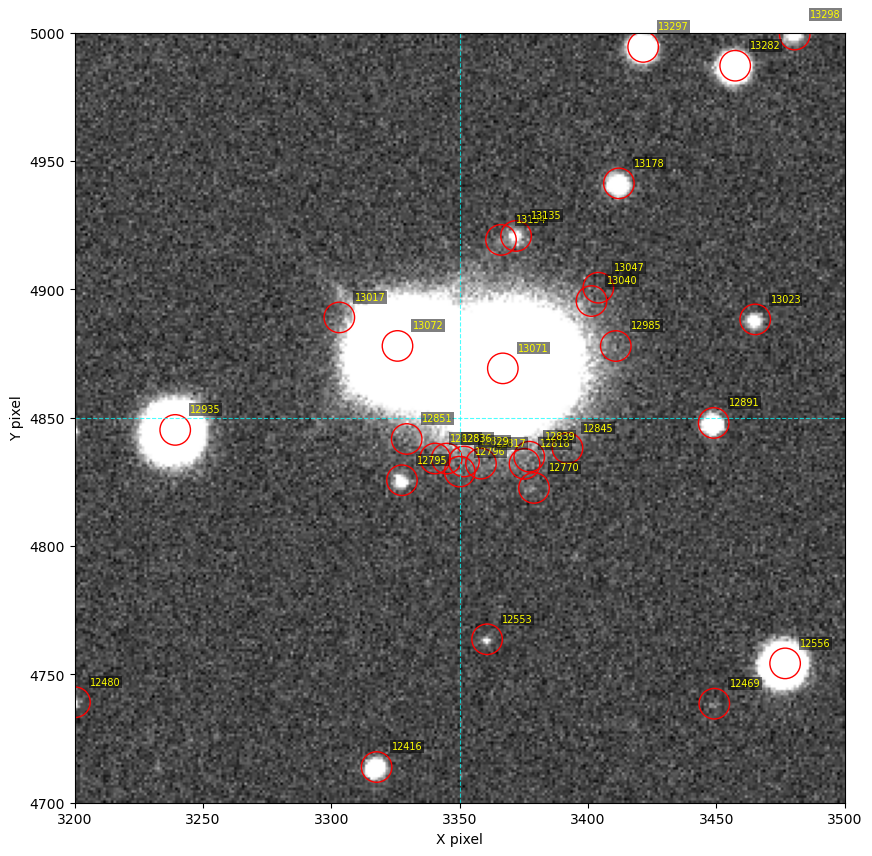

In [44]:
detection_image_path = Path('/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage.fits')
detection_image = fits.getdata(detection_image_path)
cat_multiband = Table.read('/Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/multibandphot/test_catalog.fits')
print(f'multi-band detected sources : {len(cat_multiband)}')
plot_ImageAndDetectedSources(detection_image, cat_multiband, center_point=[3350, 4850], length=300)

# 3. Matching